# Classification sur le dataset préparé
Cette section charge les fichiers `prepared_dataset_train.csv` et `prepared_dataset_test.csv` générés par le script de préparation, puis explore et évalue différents modèles de classification (Régression Logistique, Random Forest, Gradient Boosting, etc.) pour prédire l'attrition. L'accent est mis sur une méthodologie robuste, évitant les fuites de données avec des Pipelines, et traitant le déséquilibre des classes.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split, KFold, cross_validate, cross_val_predict
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score,
    matthews_corrcoef,
    average_precision_score,
    brier_score_loss,
    auc,
    roc_curve
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
# Brique 1 - Chargement des données d'entraînement et de test
df_train = pd.read_csv('prepared_dataset_train.csv')
df_test = pd.read_csv('prepared_dataset_test.csv')

print("Shape du dataset d'entraînement :", df_train.shape)
print("Shape du dataset de test/validation :", df_test.shape)

target_candidates = ['Attrition_Yes', 'Attrition']
target_col = next((c for c in target_candidates if c in df_train.columns), None)
if target_col is None:
    raise ValueError(f"Colonne cible introuvable. Colonnes attendues: {target_candidates}")

# Extraction des features et de la cible pour l'entraînement
X_train = df_train.drop(columns=[target_col])
y_train = df_train[target_col].astype(float)

# Extraction des features et de la cible pour la validation/test
X_valid = df_test.drop(columns=[target_col])
y_valid = df_test[target_col].astype(float)

# Reconstitution optionnelle de X et y globaux pour conserver la compatibilité avec la validation croisée plus bas (Brique 3)
X = pd.concat([X_train, X_valid], axis=0).reset_index(drop=True)
y = pd.concat([y_train, y_valid], axis=0).reset_index(drop=True)
df = pd.concat([df_train, df_test], axis=0).reset_index(drop=True)

print(f"\nTrain: {X_train.shape[0]} lignes")
print(f"Validation: {X_valid.shape[0]} lignes")
print(f"Total: {X.shape[0]} lignes")

Shape du dataset d'entraînement : (3528, 42)
Shape du dataset de test/validation : (882, 42)

Train: 3528 lignes
Validation: 882 lignes
Total: 4410 lignes


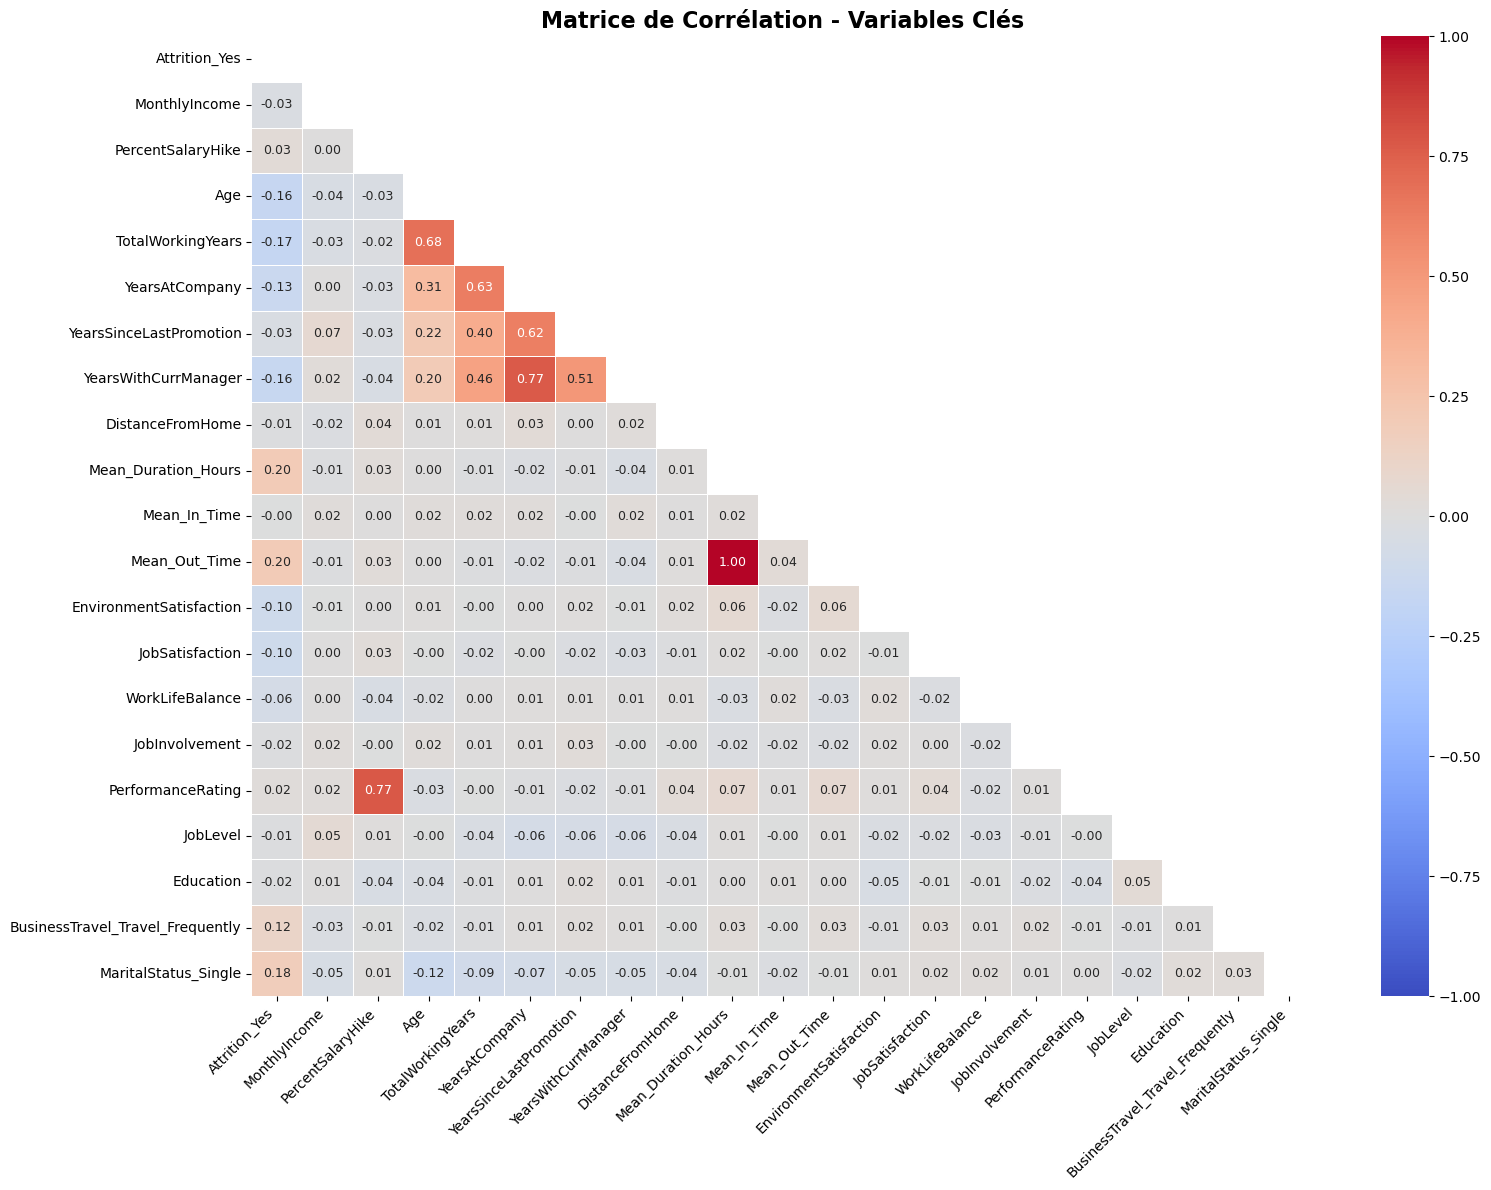

In [4]:
# Brique 4 - Matrice de corrélation sélective
# Sélection des variables continues, ordinales et de la cible pour éviter une matrice illisible
cols_to_correlate = [
    target_col,  # La cible (ex: Attrition_Yes)
    
    # Variables Numériques Continues
    'MonthlyIncome', 'PercentSalaryHike', 'Age', 
    'TotalWorkingYears', 'YearsAtCompany', 'YearsSinceLastPromotion', 
    'YearsWithCurrManager', 'DistanceFromHome',
    'Mean_Duration_Hours', 'Mean_In_Time', 'Mean_Out_Time',
    
    # Variables Ordinales
    'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance',
    'JobInvolvement', 'PerformanceRating', 'JobLevel', 'Education',
    
    # Exemples de dummies très pertinentes
    'BusinessTravel_Travel_Frequently',
    'MaritalStatus_Single'
]

# Ne conserver que les colonnes réellement présentes dans df
existing_cols = [c for c in cols_to_correlate if c in df.columns]

# Création de la matrice de corrélation
corr_matrix = df[existing_cols].corr()

# Nettoyage visuel de la matrice (triangle supérieur masqué pour plus de clarté)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5,
    vmin=-1, 
    vmax=1,
    annot_kws={"size": 9}
)
plt.title('Matrice de Corrélation - Variables Clés', fontsize=16, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Analyse Détaillée et Modèle de Régression Logistique
Suite à la régression linéaire, nous passons à une approche de classification plus standard (Régression Logistique) avec une analyse de la distribution et des relations.

/tmp/ipykernel_3018/1054874567.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=target_col, data=df, ax=ax, palette='Set2')


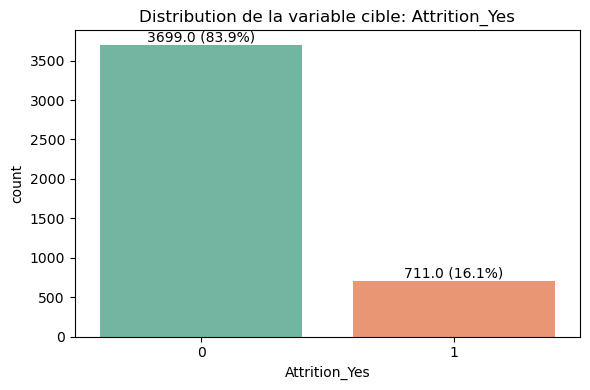

In [5]:
# Brique 7 - Analyse de la distribution de la variable cible
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=target_col, data=df, ax=ax, palette='Set2')
ax.set_title("Distribution de la variable cible: {}".format(target_col))
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({(p.get_height()/len(df)):.1%})', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

Corrélation avec l'Attrition:
Mean_Duration_Hours                 0.201191
Mean_Out_Time                       0.201099
MaritalStatus_Single                0.175419
TotalWorkingYears                  -0.170162
Age                                -0.159205
YearsWithCurrManager               -0.156199
YearsAtCompany                     -0.134392
BusinessTravel_Travel_Frequently    0.115143
JobSatisfaction                    -0.104017
EnvironmentSatisfaction            -0.101625
dtype: float64


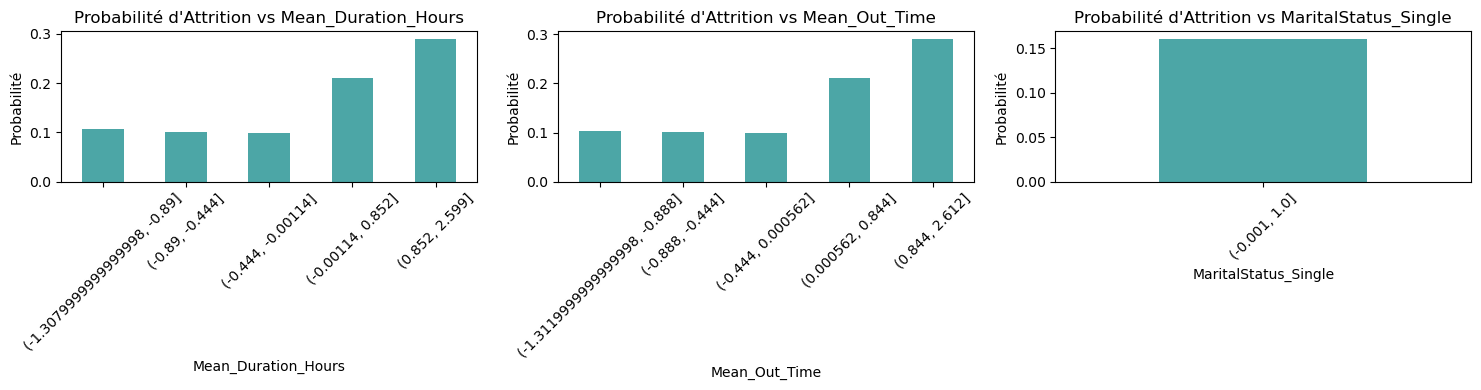

In [6]:
# Brique 8 - Relations entre les variables et la cible (Probabilité d'attrition)

# Variables numériques intéressantes potentielles (par ex. Age, DistanceFromHome, MonthlyIncome)
numeric_cols = df.select_dtypes(include='number').columns.drop(target_col, errors='ignore')
corr_with_target = df[numeric_cols].apply(lambda x: x.corr(df[target_col]))

print("Corrélation avec l'Attrition:")
print(corr_with_target.sort_values(key=abs, ascending=False).head(10))

# Visualisons l'attrition par rapport à une ou deux variables les plus corrélées
top_corr_vars = corr_with_target.sort_values(key=abs, ascending=False).index[:3]
fig, axes = plt.subplots(1, len(top_corr_vars), figsize=(15, 4))
for i, var in enumerate(top_corr_vars):
    # Regrouper en tranches (bins) pour estimer la probabilité
    bins = pd.qcut(df[var], q=5, duplicates='drop')
    prob_attrition = df.groupby(bins, observed=False)[target_col].mean()
    
    prob_attrition.plot(kind='bar', ax=axes[i], color='teal', alpha=0.7)
    axes[i].set_title(f"Probabilité d'Attrition vs {var}")
    axes[i].set_ylabel("Probabilité")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [7]:
# Brique 9 - Pipeline de Préparation et Régression Logistique (80/20)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, auc,
    classification_report
)

# Note : On conserve nos sets 'X_train' et 'X_valid' importés depuis nos datasets séparés au début du document.
# Le ré-échantillonnage n'est plus utile ici.

# Pipeline: Normalisation -> Régression Logistique
pipeline_logreg = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)) 
    # use class_weight='balanced' especially due to class imbalance seen in linear model recall
])

print("Entraînement de la Régression Logistique...")
pipeline_logreg.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba = pipeline_logreg.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_logreg = pipeline_logreg.predict(X_valid)

# Indicateurs de base
acc = accuracy_score(y_valid, y_pred_logreg)
prec = precision_score(y_valid, y_pred_logreg)
rec = recall_score(y_valid, y_pred_logreg)
f1 = f1_score(y_valid, y_pred_logreg)

print(f"\nPerformances sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc:.4f}")
print(f"Précision : {prec:.4f}")
print(f"Rappel    : {rec:.4f}")
print(f"F1-score  : {f1:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_logreg))

Entraînement de la Régression Logistique...

Performances sur l'échantillon de validation (N=882):
Accuracy  : 0.7710
Précision : 0.3872
Rappel    : 0.7254
F1-score  : 0.5049

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.94      0.78      0.85       740
         1.0       0.39      0.73      0.50       142

    accuracy                           0.77       882
   macro avg       0.66      0.75      0.68       882
weighted avg       0.85      0.77      0.80       882



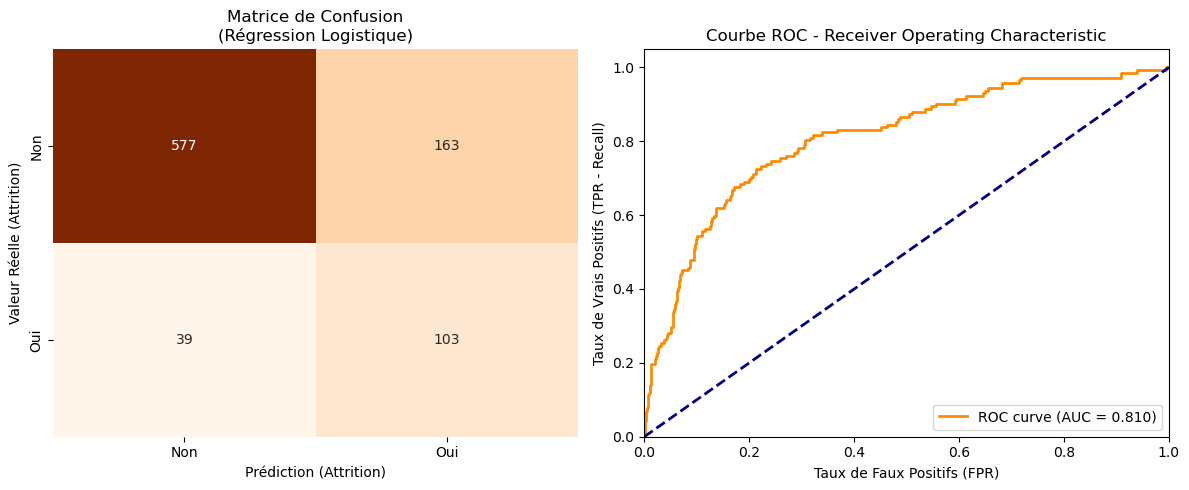

In [8]:
# Brique 10 - Matrice de Confusion et Courbe ROC / AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_logreg = confusion_matrix(y_valid, y_pred_logreg)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(Régression Logistique)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr, tpr, thresholds = roc_curve(y_valid, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Receiver Operating Characteristic")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Modèle de Classification : Arbre de Décision
Mise en place d'un modèle d'arbre de décision pour comparer ses performances avec la régression logistique.

In [9]:
# Brique 11 - Pipeline et Entraînement de l'Arbre de Décision (80/20)

from sklearn.tree import DecisionTreeClassifier

# Pipeline: Normalisation -> Arbre de Décision
# Note : L'arbre de décision n'a pas strictement besoin d'une normalisation, mais nous gardons le StandardScaler 
# pour rester cohérents par rapport à la pipeline précédente.
pipeline_dt = Pipeline([
    ('scaler', StandardScaler()),
    ('dt', DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)) 
    # Profondeur limitée (5) pour éviter un surapprentissage excessif (overfitting)
])

print("Entraînement de l'Arbre de Décision...")
pipeline_dt.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_dt = pipeline_dt.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_dt = pipeline_dt.predict(X_valid)

# Indicateurs de base
acc_dt = accuracy_score(y_valid, y_pred_dt)
prec_dt = precision_score(y_valid, y_pred_dt)
rec_dt = recall_score(y_valid, y_pred_dt)
f1_dt = f1_score(y_valid, y_pred_dt)

print(f"\nPerformances de l'Arbre sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_dt:.4f}")
print(f"Précision : {prec_dt:.4f}")
print(f"Rappel    : {rec_dt:.4f}")
print(f"F1-score  : {f1_dt:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_dt))

Entraînement de l'Arbre de Décision...

Performances de l'Arbre sur l'échantillon de validation (N=882):
Accuracy  : 0.7846
Précision : 0.4032
Rappel    : 0.7042
F1-score  : 0.5128

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.93      0.80      0.86       740
         1.0       0.40      0.70      0.51       142

    accuracy                           0.78       882
   macro avg       0.67      0.75      0.69       882
weighted avg       0.85      0.78      0.81       882



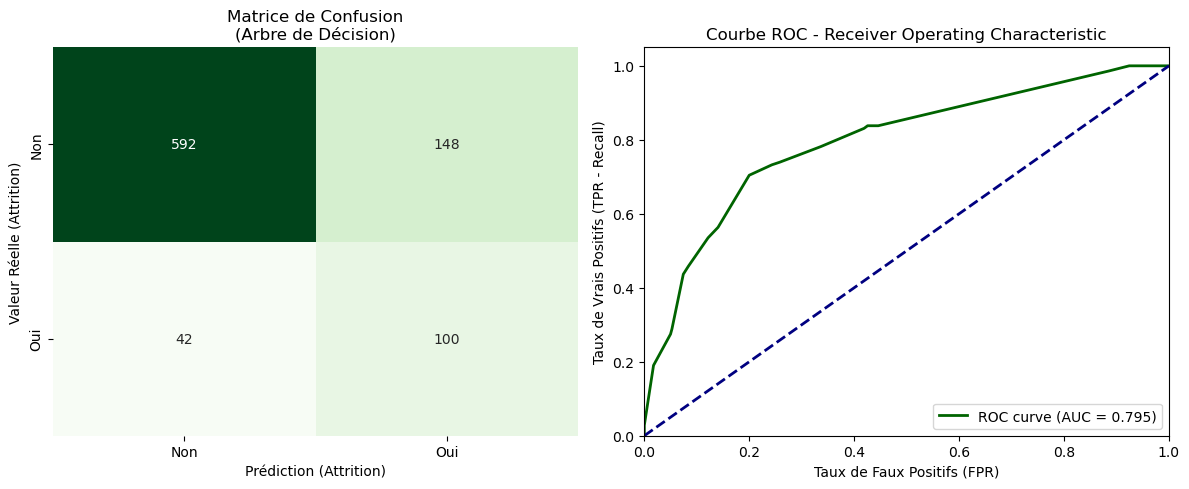

In [10]:
# Brique 12 - Matrice de Confusion et Courbe ROC / AUC (Arbre de Décision)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_dt = confusion_matrix(y_valid, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(Arbre de Décision)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_valid, y_pred_proba_dt)
roc_auc_dt = auc(fpr_dt, tpr_dt)

ax2.plot(fpr_dt, tpr_dt, color='darkgreen', lw=2, label=f'ROC curve (AUC = {roc_auc_dt:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Receiver Operating Characteristic")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [16]:
# Brique 13 - Visualisation 3D Plotly avec attrition en axe Z (Arbre)

# Définition des variables pour la visualisation 3D en prenant les 2 variables numériques les plus corrélées à la cible si disponibles
try:
    available_xy_features = list(top_corr_vars[:2])
except NameError:
    # Solution de repli si top_corr_vars n'est pas défini
    numeric_cols = X_valid.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
    available_xy_features = numeric_cols[:2] if len(numeric_cols) >= 2 else []

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques disponibles pour X et Y.')
else:
    import plotly.graph_objects as go
    
    viz_df = X_valid[available_xy_features].copy()
    viz_df['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df['Prediction_Classe'] = y_pred_dt.astype(int)
    viz_df['Prediction_Proba'] = y_pred_proba_dt

    hover_text = [
        f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite (Classe 1): {p:.3f}"
        for a, pc, p in zip(
            viz_df['Attrition_Reelle'],
            viz_df['Prediction_Classe'],
            viz_df['Prediction_Proba']
        )
    ]

    fig = go.Figure(
        data=[
            go.Scatter3d(
                x=viz_df[available_xy_features[0]],
                y=viz_df[available_xy_features[1]],
                z=viz_df['Attrition_Reelle'],
                mode='markers',
                marker=dict(
                    size=5,
                    color=viz_df['Prediction_Classe'],
                    colorscale='Viridis',
                    cmin=0,
                    cmax=1,
                    opacity=0.8,
                    colorbar=dict(title='Classe predite (0/1)')
                ),
                text=hover_text,
                hovertemplate='%{text}<extra></extra>'
            )
        ]
    )

    fig.update_layout(
        title='Visualisation 3D (Arbre de Decision) - Attrition reelle en axe Z',
        scene=dict(
            xaxis_title=available_xy_features[0],
            yaxis_title=available_xy_features[1],
            zaxis_title='Attrition reelle (0/1)',
            zaxis=dict(tickmode='array', tickvals=[0, 1])
        ),
        margin=dict(l=0, r=0, b=0, t=45)
    )

    fig.show()

# Modèle de Classification : K-Nearest Neighbors (KNN)
Mise en place d'un modèle basé sur les k plus proches voisins. Note : L'analyse de la distribution de la classe cible et les corrélations avec d'autres variables ont été couvertes dans les Briques 7 et 8 ci-dessus.

In [17]:
# Brique 14 - Pipeline et Entraînement KNN (80/20)

from sklearn.neighbors import KNeighborsClassifier

# Pipeline: Normalisation -> KNN
# La normalisation est CRUCIALE pour KNN car il se base sur la distance spatiale
pipeline_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
])

print("Entraînement du modèle K-Nearest Neighbors...")
pipeline_knn.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_knn = pipeline_knn.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_knn = pipeline_knn.predict(X_valid)

# Indicateurs de base
acc_knn = accuracy_score(y_valid, y_pred_knn)
prec_knn = precision_score(y_valid, y_pred_knn)
rec_knn = recall_score(y_valid, y_pred_knn)
f1_knn = f1_score(y_valid, y_pred_knn)

print(f"\nPerformances du KNN sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_knn:.4f}")
print(f"Précision : {prec_knn:.4f}")
print(f"Rappel    : {rec_knn:.4f}")
print(f"F1-score  : {f1_knn:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_knn))

Entraînement du modèle K-Nearest Neighbors...

Performances du KNN sur l'échantillon de validation (N=882):
Accuracy  : 0.9717
Précision : 0.9756
Rappel    : 0.8451
F1-score  : 0.9057

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.97      1.00      0.98       740
         1.0       0.98      0.85      0.91       142

    accuracy                           0.97       882
   macro avg       0.97      0.92      0.94       882
weighted avg       0.97      0.97      0.97       882



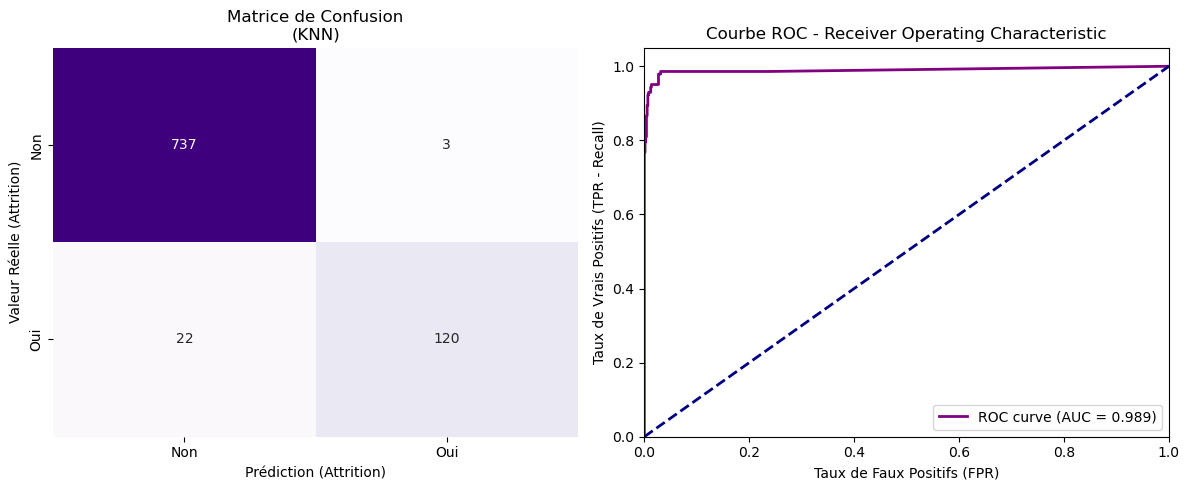

In [18]:
# Brique 15 - Matrice de Confusion et Courbe ROC / AUC (KNN)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_knn = confusion_matrix(y_valid, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Purples', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(KNN)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_knn, tpr_knn, thresholds_knn = roc_curve(y_valid, y_pred_proba_knn)
roc_auc_knn = auc(fpr_knn, tpr_knn)

ax2.plot(fpr_knn, tpr_knn, color='purple', lw=2, label=f'ROC curve (AUC = {roc_auc_knn:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Receiver Operating Characteristic")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [19]:
# Brique 16 - Visualisation 3D Plotly avec attrition en axe Z (KNN)

# On s'assure d'avoir `available_xy_features` défini (identique à la cellule Brique 13)
try:
    available_xy_features = list(top_corr_vars[:2])
except NameError:
    numeric_cols = X_valid.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
    available_xy_features = numeric_cols[:2] if len(numeric_cols) >= 2 else []

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques disponibles pour X et Y.')
else:
    import plotly.graph_objects as go
    
    viz_df_knn = X_valid[available_xy_features].copy()
    viz_df_knn['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df_knn['Prediction_Classe'] = y_pred_knn.astype(int)
    viz_df_knn['Prediction_Proba'] = y_pred_knn.astype(int) if 'y_pred_proba_knn' not in locals() else y_pred_proba_knn

    hover_text_knn = [
        f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite (Classe 1): {p:.3f}"
        for a, pc, p in zip(
            viz_df_knn['Attrition_Reelle'],
            viz_df_knn['Prediction_Classe'],
            viz_df_knn['Prediction_Proba']
        )
    ]

    fig_knn = go.Figure(
        data=[
            go.Scatter3d(
                x=viz_df_knn[available_xy_features[0]],
                y=viz_df_knn[available_xy_features[1]],
                z=viz_df_knn['Attrition_Reelle'],
                mode='markers',
                marker=dict(
                    size=5,
                    color=viz_df_knn['Prediction_Classe'],
                    colorscale='Purples',
                    cmin=0,
                    cmax=1,
                    opacity=0.8,
                    colorbar=dict(title='Classe predite (0/1)')
                ),
                text=hover_text_knn,
                hovertemplate='%{text}<extra></extra>'
            )
        ]
    )

    fig_knn.update_layout(
        title='Visualisation 3D (KNN) - Attrition reelle en axe Z',
        scene=dict(
            xaxis_title=available_xy_features[0],
            yaxis_title=available_xy_features[1],
            zaxis_title='Attrition reelle (0/1)',
            zaxis=dict(tickmode='array', tickvals=[0, 1])
        ),
        margin=dict(l=0, r=0, b=0, t=45)
    )

    fig_knn.show()

# Modèle de Classification : Support Vector Machine (SVM)
Mise en place d'un modèle basé sur les machines à vecteurs de support (SVM). Note : L'analyse de la distribution de la classe cible et les corrélations avec d'autres variables ont été couvertes dans les Briques 7 et 8.

In [20]:
# Brique 17 - Pipeline et Entraînement SVM (80/20)

from sklearn.svm import SVC

# Pipeline: Normalisation -> SVM
# La normalisation est également critique pour le SVM
pipeline_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42))
])

print("Entraînement du modèle Support Vector Machine (SVM)...")
pipeline_svm.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_svm = pipeline_svm.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_svm = pipeline_svm.predict(X_valid)

# Indicateurs de base
acc_svm = accuracy_score(y_valid, y_pred_svm)
prec_svm = precision_score(y_valid, y_pred_svm)
rec_svm = recall_score(y_valid, y_pred_svm)
f1_svm = f1_score(y_valid, y_pred_svm)

print(f"\nPerformances du SVM sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_svm:.4f}")
print(f"Précision : {prec_svm:.4f}")
print(f"Rappel    : {rec_svm:.4f}")
print(f"F1-score  : {f1_svm:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_svm))

Entraînement du modèle Support Vector Machine (SVM)...

Performances du SVM sur l'échantillon de validation (N=882):
Accuracy  : 0.9320
Précision : 0.7278
Rappel    : 0.9225
F1-score  : 0.8137

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.98      0.93      0.96       740
         1.0       0.73      0.92      0.81       142

    accuracy                           0.93       882
   macro avg       0.86      0.93      0.89       882
weighted avg       0.94      0.93      0.94       882



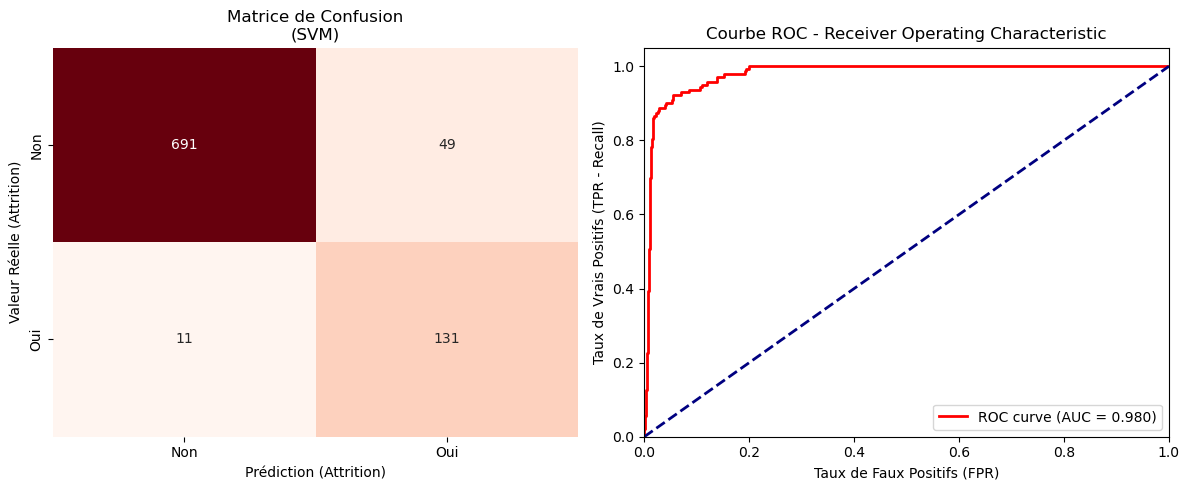

In [21]:
# Brique 18 - Matrice de Confusion et Courbe ROC / AUC (SVM)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_svm = confusion_matrix(y_valid, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Reds', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(SVM)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_valid, y_pred_proba_svm)
roc_auc_svm = auc(fpr_svm, tpr_svm)

ax2.plot(fpr_svm, tpr_svm, color='red', lw=2, label=f'ROC curve (AUC = {roc_auc_svm:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Receiver Operating Characteristic")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [22]:
# Brique 19 - Visualisation 3D Plotly avec attrition en axe Z (SVM)

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques disponibles pour X et Y.')
else:
    viz_df_svm = X_valid[available_xy_features].copy()
    viz_df_svm['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df_svm['Prediction_Classe'] = y_pred_svm.astype(int)
    viz_df_svm['Prediction_Proba'] = y_pred_proba_svm

    hover_text_svm = [
        f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite (Classe 1): {p:.3f}"
        for a, pc, p in zip(
            viz_df_svm['Attrition_Reelle'],
            viz_df_svm['Prediction_Classe'],
            viz_df_svm['Prediction_Proba']
        )
    ]

    fig_svm = go.Figure(
        data=[
            go.Scatter3d(
                x=viz_df_svm[available_xy_features[0]],
                y=viz_df_svm[available_xy_features[1]],
                z=viz_df_svm['Attrition_Reelle'],
                mode='markers',
                marker=dict(
                    size=5,
                    color=viz_df_svm['Prediction_Classe'],
                    colorscale='Reds',
                    cmin=0,
                    cmax=1,
                    opacity=0.8,
                    colorbar=dict(title='Classe predite (0/1)')
                ),
                text=hover_text_svm,
                hovertemplate='%{text}<extra></extra>'
            )
        ]
    )

    fig_svm.update_layout(
        title='Visualisation 3D (SVM) - Attrition reelle en axe Z',
        scene=dict(
            xaxis_title=available_xy_features[0],
            yaxis_title=available_xy_features[1],
            zaxis_title='Attrition reelle (0/1)',
            zaxis=dict(tickmode='array', tickvals=[0, 1])
        ),
        margin=dict(l=0, r=0, b=0, t=45)
    )

    fig_svm.show()

# Modèle de Classification : Naive Bayes
Mise en place d'un modèle Naive Bayes (Gaussien). L'analyse de la distribution de la classe cible et les corrélations avec d'autres variables restent valables et ont été définies dans les Briques 7 et 8.

In [23]:
# Brique 20 - Pipeline et Entraînement Naive Bayes (80/20)

from sklearn.naive_bayes import GaussianNB

# Pipeline: Normalisation -> Gaussian Naive Bayes
# (Bien que Naive Bayes ne nécessite pas strictement une mise à l'échelle, 
# la maintenir permet une comparaison directe sur les mêmes caractéristiques standardisées)
pipeline_nb = Pipeline([
    ('scaler', StandardScaler()),
    ('nb', GaussianNB())
])

print("Entraînement du modèle Naive Bayes Gaussien...")
pipeline_nb.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_nb = pipeline_nb.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_nb = pipeline_nb.predict(X_valid)

# Indicateurs de base
acc_nb = accuracy_score(y_valid, y_pred_nb)
prec_nb = precision_score(y_valid, y_pred_nb)
rec_nb = recall_score(y_valid, y_pred_nb)
f1_nb = f1_score(y_valid, y_pred_nb)

print(f"\nPerformances du Naive Bayes sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_nb:.4f}")
print(f"Précision : {prec_nb:.4f}")
print(f"Rappel    : {rec_nb:.4f}")
print(f"F1-score  : {f1_nb:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_nb))

Entraînement du modèle Naive Bayes Gaussien...

Performances du Naive Bayes sur l'échantillon de validation (N=882):
Accuracy  : 0.8175
Précision : 0.4395
Rappel    : 0.4859
F1-score  : 0.4615

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.90      0.88      0.89       740
         1.0       0.44      0.49      0.46       142

    accuracy                           0.82       882
   macro avg       0.67      0.68      0.68       882
weighted avg       0.83      0.82      0.82       882



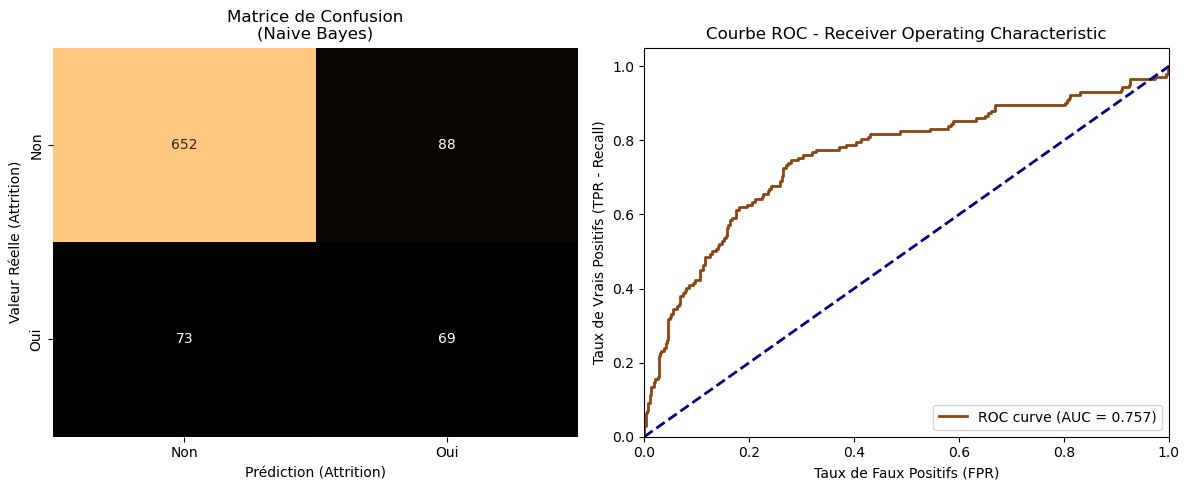

In [24]:
# Brique 21 - Matrice de Confusion et Courbe ROC / AUC (Naive Bayes)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_nb = confusion_matrix(y_valid, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='copper', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(Naive Bayes)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_valid, y_pred_proba_nb)
roc_auc_nb = auc(fpr_nb, tpr_nb)

ax2.plot(fpr_nb, tpr_nb, color='saddlebrown', lw=2, label=f'ROC curve (AUC = {roc_auc_nb:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Receiver Operating Characteristic")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [25]:
# Brique 22 - Visualisation 3D Plotly avec attrition en axe Z (Naive Bayes)

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques disponibles pour X et Y.')
else:
    viz_df_nb = X_valid[available_xy_features].copy()
    viz_df_nb['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df_nb['Prediction_Classe'] = y_pred_nb.astype(int)
    viz_df_nb['Prediction_Proba'] = y_pred_proba_nb

    hover_text_nb = [
        f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite (Classe 1): {p:.3f}"
        for a, pc, p in zip(
            viz_df_nb['Attrition_Reelle'],
            viz_df_nb['Prediction_Classe'],
            viz_df_nb['Prediction_Proba']
        )
    ]

    fig_nb = go.Figure(
        data=[
            go.Scatter3d(
                x=viz_df_nb[available_xy_features[0]],
                y=viz_df_nb[available_xy_features[1]],
                z=viz_df_nb['Attrition_Reelle'],
                mode='markers',
                marker=dict(
                    size=5,
                    color=viz_df_nb['Prediction_Classe'],
                    colorscale='purp',
                    cmin=0,
                    cmax=1,
                    opacity=0.8,
                    colorbar=dict(title='Classe predite (0/1)')
                ),
                text=hover_text_nb,
                hovertemplate='%{text}<extra></extra>'
            )
        ]
    )

    fig_nb.update_layout(
        title='Visualisation 3D (Naive Bayes) - Attrition reelle en axe Z',
        scene=dict(
            xaxis_title=available_xy_features[0],
            yaxis_title=available_xy_features[1],
            zaxis_title='Attrition reelle (0/1)',
            zaxis=dict(tickmode='array', tickvals=[0, 1])
        ),
        margin=dict(l=0, r=0, b=0, t=45)
    )

    fig_nb.show()

# Comparaison des Modèles de Base (Simplistes)
Avant d'aborder les modèles ensemblistes, examinons et comparons synthétiquement l'efficacité de nos modèles "simples" sur le set de validation (Régression logistique, Arbre de décision, KNN, SVM, et Naive Bayes). Nous allons particulièrement concentrer notre attention sur le **Rappel (Recall)**, le **F1-Score** et examiner l'aire sous la courbe **Precision-Recall (PR-AUC)**.

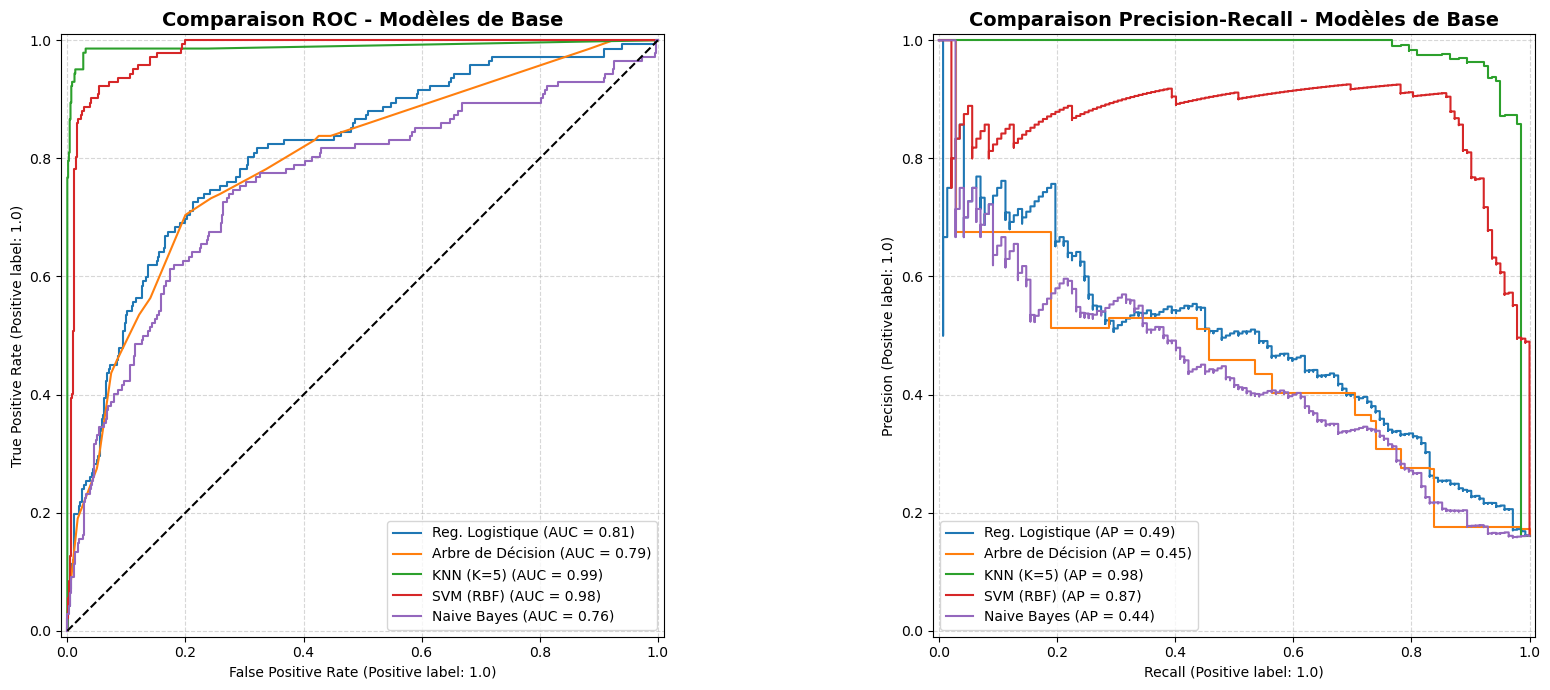


--- Tableau Récapitulatif (Trié par F1-Score) ---


,F1-Score,Recall (Rappel),Precision,Accuracy
Modèle,,,,
KNN (K=5),0.905660,0.845070,0.975610,0.971655
SVM (RBF),0.813665,0.922535,0.727778,0.931973
Arbre de Décision,0.512821,0.704225,0.403226,0.784580
Reg. Logistique,0.504902,0.725352,0.387218,0.770975
Naive Bayes,0.461538,0.485915,0.439490,0.817460


In [26]:
# Brique 22.5 - Comparaison des Modèles de Base (Simplistes)
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

# Regroupement des modèles de base
basic_pipelines = {
    'Reg. Logistique': pipeline_logreg,
    'Arbre de Décision': pipeline_dt,
    'KNN (K=5)': pipeline_knn,
    'SVM (RBF)': pipeline_svm,
    'Naive Bayes': pipeline_nb
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# 1. Courbes ROC
for name, p in basic_pipelines.items():
    RocCurveDisplay.from_estimator(p, X_valid, y_valid, ax=ax1, name=name)
ax1.set_title("Comparaison ROC - Modèles de Base", fontsize=14, weight='bold')
ax1.plot([0, 1], [0, 1], linestyle='--', color='black') # Ligne de chance
ax1.grid(True, linestyle='--', alpha=0.5)

# 2. Courbes Precision-Recall
for name, p in basic_pipelines.items():
    PrecisionRecallDisplay.from_estimator(p, X_valid, y_valid, ax=ax2, name=name)
ax2.set_title("Comparaison Precision-Recall - Modèles de Base", fontsize=14, weight='bold')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Tableau recapitulatif (sur Validation)
recap_data = []
for name, p in basic_pipelines.items():
    y_pred_tmp = p.predict(X_valid)
    recap_data.append({
        'Modèle': name,
        'F1-Score': f1_score(y_valid, y_pred_tmp),
        'Recall (Rappel)': recall_score(y_valid, y_pred_tmp),
        'Precision': precision_score(y_valid, y_pred_tmp),
        'Accuracy': accuracy_score(y_valid, y_pred_tmp)
    })

df_recap_basic = pd.DataFrame(recap_data).sort_values(by='F1-Score', ascending=False).set_index('Modèle')
print("\n--- Tableau Récapitulatif (Trié par F1-Score) ---")
display(df_recap_basic)

# 2. Modèles Ensemblistes (La force du nombre)
L'idée des modèles ensemblistes est de créer plusieurs modèles et de combiner leurs prédictions (vote ou moyenne) pour obtenir un résultat généralement plus robuste et plus performant.

Nous allons explorer 3 méthodes :
1. **Bagging (Random Forest)** : Plusieurs arbres parallèles.
2. **Boosting (Gradient Boosting / AdaBoost)** : Entraînement en série pour corriger les erreurs. (Nous utiliserons ici `GradientBoostingClassifier`, l'équivalent robuste intégré à `scikit-learn` pour le XGBoost).
3. **Stacking** : Un méta-modèle qui décide comment pondérer un Random Forest, un SVM et un KNN.

In [27]:
# Brique 23 - A. Le Bagging : Random Forest (Entraînement)
from sklearn.ensemble import RandomForestClassifier

pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42))
])

print("Entraînement du modèle Random Forest avec class_weight='balanced'...")
pipeline_rf.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_rf = pipeline_rf.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_rf = pipeline_rf.predict(X_valid)

# Indicateurs de base
acc_rf = accuracy_score(y_valid, y_pred_rf)
prec_rf = precision_score(y_valid, y_pred_rf)
rec_rf = recall_score(y_valid, y_pred_rf)
f1_rf = f1_score(y_valid, y_pred_rf)
pr_auc_rf = average_precision_score(y_valid, y_pred_proba_rf)

print(f"\nPerformances de Random Forest sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_rf:.4f}")
print(f"Précision : {prec_rf:.4f}")
print(f"Rappel    : {rec_rf:.4f}")
print(f"F1-score  : {f1_rf:.4f}")
print(f"PR AUC    : {pr_auc_rf:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_rf))

Entraînement du modèle Random Forest avec class_weight='balanced'...

Performances de Random Forest sur l'échantillon de validation (N=882):
Accuracy  : 0.9921
Précision : 1.0000
Rappel    : 0.9507
F1-score  : 0.9747
PR AUC    : 0.9922

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       740
         1.0       1.00      0.95      0.97       142

    accuracy                           0.99       882
   macro avg       1.00      0.98      0.99       882
weighted avg       0.99      0.99      0.99       882



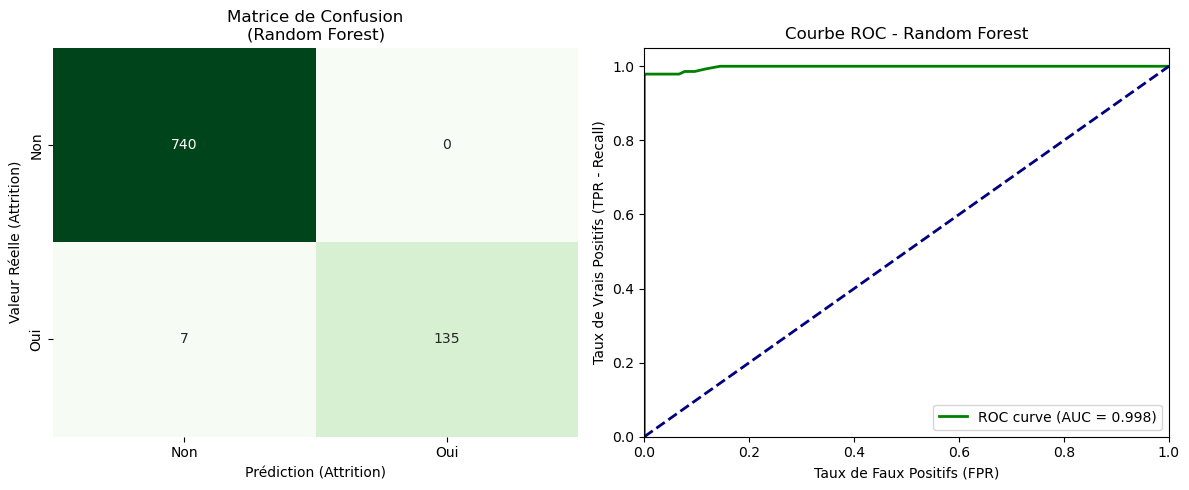

In [28]:
# Brique 24 - Matrice de Confusion et Courbe ROC / AUC (Random Forest)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_rf = confusion_matrix(y_valid, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(Random Forest)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_valid, y_pred_proba_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

ax2.plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'ROC curve (AUC = {roc_auc_rf:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Random Forest")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [29]:
# Brique 25 - Visualisation 3D Plotly avec attrition en axe Z (Random Forest)

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques...')
else:
    viz_df_rf = X_valid[available_xy_features].copy()
    viz_df_rf['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df_rf['Prediction_Classe'] = y_pred_rf.astype(int)
    viz_df_rf['Prediction_Proba'] = y_pred_proba_rf

    hover_text_rf = [f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite: {p:.3f}" 
                     for a, pc, p in zip(viz_df_rf['Attrition_Reelle'], viz_df_rf['Prediction_Classe'], viz_df_rf['Prediction_Proba'])]

    fig_rf = go.Figure(data=[go.Scatter3d(
        x=viz_df_rf[available_xy_features[0]], y=viz_df_rf[available_xy_features[1]], z=viz_df_rf['Attrition_Reelle'], mode='markers',
        marker=dict(size=5, color=viz_df_rf['Prediction_Classe'], colorscale='Greens', cmin=0, cmax=1, opacity=0.8, colorbar=dict(title='Classe predite')),
        text=hover_text_rf, hovertemplate='%{text}<extra></extra>'
    )])

    fig_rf.update_layout(title='Visualisation 3D (Random Forest) - Attrition reelle en axe Z',
                         scene=dict(xaxis_title=available_xy_features[0], yaxis_title=available_xy_features[1], zaxis_title='Attrition reelle', zaxis=dict(tickmode='array', tickvals=[0, 1])),
                         margin=dict(l=0, r=0, b=0, t=45))
    fig_rf.show()

In [30]:
# Brique 26 - B. Le Boosting : Gradient Boosting (Entraînement)
# Le GradientBoostingClassifier n'accepte pas directement 'class_weight'. On peut utiliser un SMOTE dans le pipeline (via imblearn) si besoin,
# mais ici nous optimisons déjà via l'ensemble. 
from sklearn.ensemble import GradientBoostingClassifier

pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
])

print("Entraînement du modèle Gradient Boosting...")
pipeline_gb.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_gb = pipeline_gb.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_gb = pipeline_gb.predict(X_valid)

# Indicateurs de base
acc_gb = accuracy_score(y_valid, y_pred_gb)
prec_gb = precision_score(y_valid, y_pred_gb)
rec_gb = recall_score(y_valid, y_pred_gb)
f1_gb = f1_score(y_valid, y_pred_gb)
pr_auc_gb = average_precision_score(y_valid, y_pred_proba_gb)

print(f"\nPerformances de Gradient Boosting sur l'échantillon validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_gb:.4f}")
print(f"Précision : {prec_gb:.4f}")
print(f"Rappel    : {rec_gb:.4f}")
print(f"F1-score  : {f1_gb:.4f}")
print(f"PR AUC    : {pr_auc_gb:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_gb))

Entraînement du modèle Gradient Boosting...

Performances de Gradient Boosting sur l'échantillon validation (N=882):
Accuracy  : 0.8968
Précision : 0.8923
Rappel    : 0.4085
F1-score  : 0.5604
PR AUC    : 0.7602

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       0.90      0.99      0.94       740
         1.0       0.89      0.41      0.56       142

    accuracy                           0.90       882
   macro avg       0.89      0.70      0.75       882
weighted avg       0.90      0.90      0.88       882



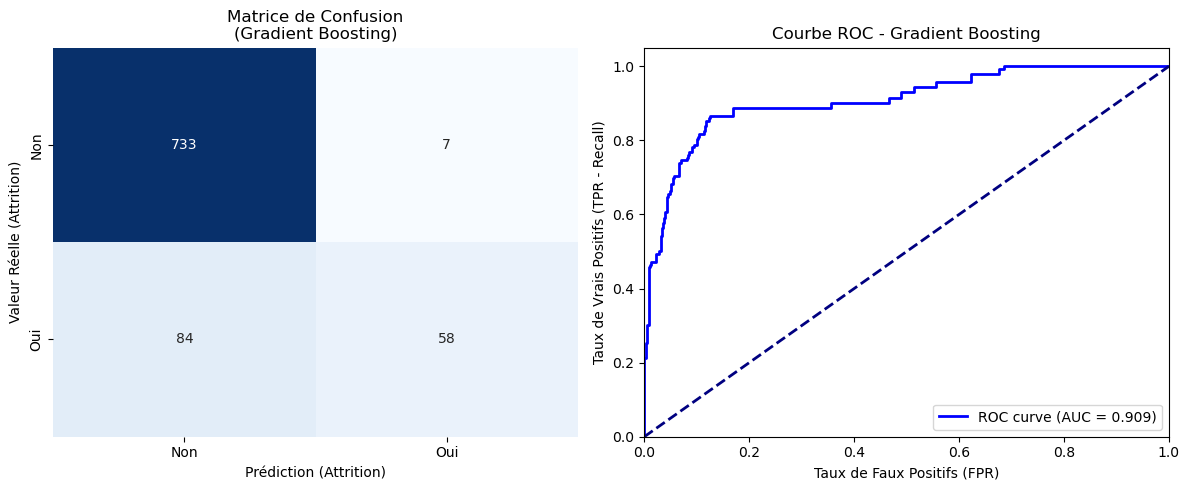

In [31]:
# Brique 27 - Matrice de Confusion et Courbe ROC / AUC (Gradient Boosting)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# 1. Matrice de Confusion
cm_gb = confusion_matrix(y_valid, y_pred_gb)
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Non', 'Oui'], yticklabels=['Non', 'Oui'])
ax1.set_title("Matrice de Confusion\n(Gradient Boosting)")
ax1.set_xlabel("Prédiction (Attrition)")
ax1.set_ylabel("Valeur Réelle (Attrition)")

# 2. Courbe ROC
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_valid, y_pred_proba_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

ax2.plot(fpr_gb, tpr_gb, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc_gb:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Taux de Faux Positifs (FPR)')
ax2.set_ylabel('Taux de Vrais Positifs (TPR - Recall)')
ax2.set_title("Courbe ROC - Gradient Boosting")
ax2.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [32]:
# Brique 28 - Visualisation 3D Plotly avec attrition en axe Z (Gradient Boosting)

if len(available_xy_features) < 2:
    print('\nVisualisation 3D non generee: moins de 2 variables numeriques...')
else:
    viz_df_gb = X_valid[available_xy_features].copy()
    viz_df_gb['Attrition_Reelle'] = y_valid.values.astype(int)
    viz_df_gb['Prediction_Classe'] = y_pred_gb.astype(int)
    viz_df_gb['Prediction_Proba'] = y_pred_proba_gb

    hover_text_gb = [f"Attrition reelle: {int(a)}<br>Prediction classe: {int(pc)}<br>Probabilite: {p:.3f}" 
                     for a, pc, p in zip(viz_df_gb['Attrition_Reelle'], viz_df_gb['Prediction_Classe'], viz_df_gb['Prediction_Proba'])]

    fig_gb = go.Figure(data=[go.Scatter3d(
        x=viz_df_gb[available_xy_features[0]], y=viz_df_gb[available_xy_features[1]], z=viz_df_gb['Attrition_Reelle'], mode='markers',
        marker=dict(size=5, color=viz_df_gb['Prediction_Classe'], colorscale='Blues', cmin=0, cmax=1, opacity=0.8, colorbar=dict(title='Classe predite')),
        text=hover_text_gb, hovertemplate='%{text}<extra></extra>'
    )])

    fig_gb.update_layout(title='Visualisation 3D (Gradient Boosting) - Attrition reelle en axe Z',
                         scene=dict(xaxis_title=available_xy_features[0], yaxis_title=available_xy_features[1], zaxis_title='Attrition reelle', zaxis=dict(tickmode='array', tickvals=[0, 1])),
                         margin=dict(l=0, r=0, b=0, t=45))
    fig_gb.show()

In [33]:
# Brique 29 - C. Le Stacking : Méta-Modèle (Entraînement)
from sklearn.ensemble import StackingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# On choisit nos meilleurs modèles pour former une équipe : Random Forest, SVM robuste et K-Nearest Neighbors
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=50, class_weight='balanced', random_state=42)),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5, weights='distance'))
]

pipeline_stack = Pipeline([
    ('scaler', StandardScaler()),
    ('stack', StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(class_weight='balanced'),
        cv=5 # <- Important: Définit une validation croisée interne explicite (out-of-fold) pour éviter le surapprentissage du méta-modèle.
    ))
])

print("Entraînement du modèle de Stacking...")
pipeline_stack.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_stack = pipeline_stack.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_stack = pipeline_stack.predict(X_valid)

# Indicateurs de base
acc_stack = accuracy_score(y_valid, y_pred_stack)
prec_stack = precision_score(y_valid, y_pred_stack)
rec_stack = recall_score(y_valid, y_pred_stack)
f1_stack = f1_score(y_valid, y_pred_stack)
# PR-AUC pour une classe déséquilibrée
from sklearn.metrics import average_precision_score
pr_auc_stack = average_precision_score(y_valid, y_pred_proba_stack)

print(f"\nPerformances du Stacking sur l'échantillon de validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_stack:.4f}")
print(f"Précision : {prec_stack:.4f}")
print(f"Rappel    : {rec_stack:.4f}")
print(f"F1-score  : {f1_stack:.4f}")
print(f"PR AUC    : {pr_auc_stack:.4f}")
print("\nRapport de métriques Détaillé:\n", classification_report(y_valid, y_pred_stack))

Entraînement du modèle de Stacking...

Performances du Stacking sur l'échantillon de validation (N=882):
Accuracy  : 0.9875
Précision : 0.9456
Rappel    : 0.9789
F1-score  : 0.9619
PR AUC    : 0.9930

Rapport de métriques Détaillé:
               precision    recall  f1-score   support

         0.0       1.00      0.99      0.99       740
         1.0       0.95      0.98      0.96       142

    accuracy                           0.99       882
   macro avg       0.97      0.98      0.98       882
weighted avg       0.99      0.99      0.99       882



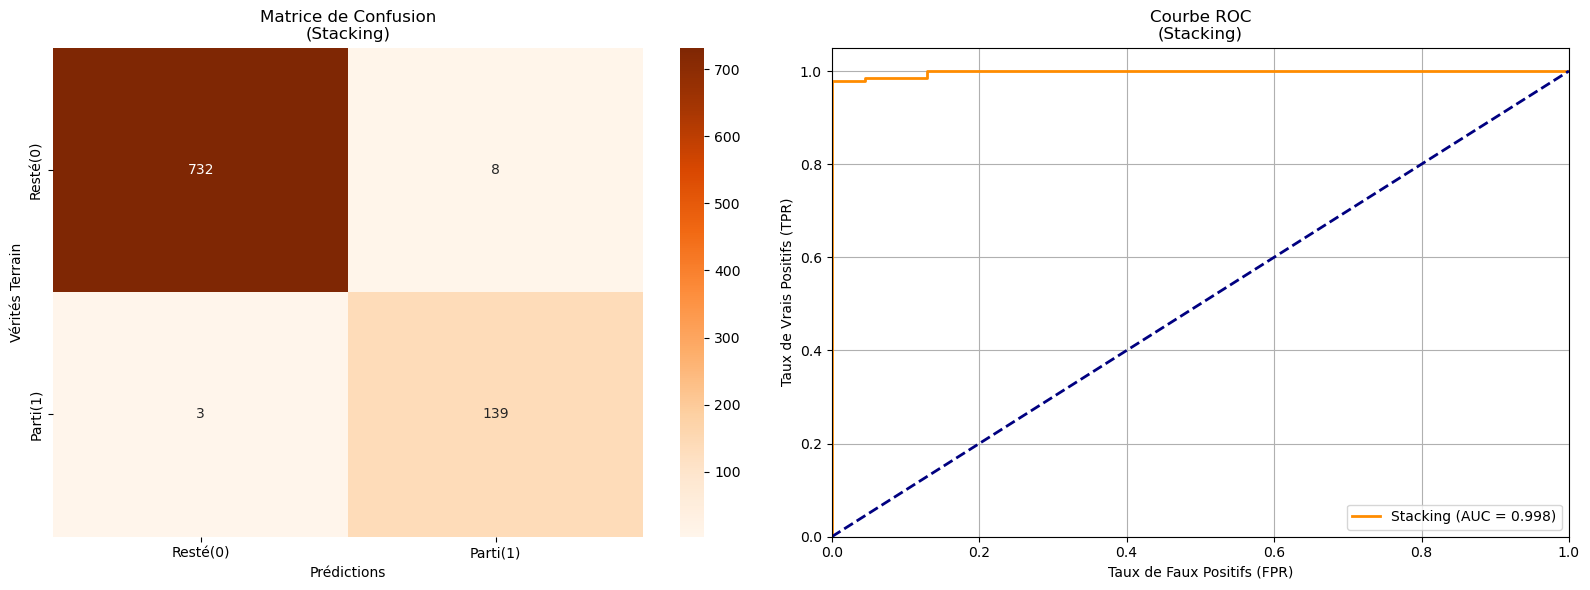

In [34]:
# Brique 30 - C. Le Stacking : Matrice de Confusion & AUC ROC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

cm_stack = confusion_matrix(y_valid, y_pred_stack)
sns.heatmap(cm_stack, annot=True, fmt='d', cmap='Oranges', ax=ax[0])
ax[0].set_title('Matrice de Confusion\n(Stacking)')
ax[0].set_xlabel('Prédictions')
ax[0].set_ylabel('Vérités Terrain')
ax[0].xaxis.set_ticklabels(['Resté(0)', 'Parti(1)'])
ax[0].yaxis.set_ticklabels(['Resté(0)', 'Parti(1)'])

# Calcul courbe et aire sous la courbe
fpr_stack, tpr_stack, _ = roc_curve(y_valid, y_pred_proba_stack)
roc_auc_stack = auc(fpr_stack, tpr_stack)

ax[1].plot(fpr_stack, tpr_stack, color='darkorange', lw=2, label=f'Stacking (AUC = {roc_auc_stack:.3f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Taux de Faux Positifs (FPR)')
ax[1].set_ylabel('Taux de Vrais Positifs (TPR)')
ax[1].set_title('Courbe ROC\n(Stacking)')
ax[1].legend(loc="lower right")
ax[1].grid(True)

plt.tight_layout()
plt.show()

In [35]:
# Brique 31 - C. Le Stacking : Visualisation Plotly 3D Interactive
import plotly.graph_objects as go
from sklearn.decomposition import PCA

print("Compression 3D...")
pca_3d = PCA(n_components=3)
X_valid_3d = pca_3d.fit_transform(X_valid)

df_vis_stack = pd.DataFrame(X_valid_3d, columns=['PC1', 'PC2', 'PC3'])
df_vis_stack['Actual'] = y_valid.values
df_vis_stack['Predicted'] = y_pred_stack

color_discrete_map = {
    (0, 0): 'blue',    # True Negatives (Correctly staying)
    (1, 1): 'red',     # True Positives (Correctly leaving)
    (0, 1): 'orange',  # False Positives (Incorrectly predicted to leave)
    (1, 0): 'purple'   # False Negatives (Incorrectly predicted to stay)
}

df_vis_stack['Status'] = df_vis_stack.apply(lambda row: 'TN' if row['Actual'] == 0 and row['Predicted'] == 0 else
                                   ('TP' if row['Actual'] == 1 and row['Predicted'] == 1 else
                                   ('FP' if row['Actual'] == 0 and row['Predicted'] == 1 else 'FN')), axis=1)

colors = df_vis_stack[['Actual', 'Predicted']].apply(lambda x: color_discrete_map[(x[0], x[1])], axis=1)

fig_scat_stack = go.Figure(data=[go.Scatter3d(
    x=df_vis_stack['PC1'],
    y=df_vis_stack['PC2'],
    z=df_vis_stack['PC3'],
    mode='markers',
    marker=dict(
        size=5,
        color=colors,
        opacity=0.8
    ),
    text=df_vis_stack['Status']
)])

fig_scat_stack.update_layout(
    title=f"Stacking : {acc_stack*100:.1f}% Acc (Bleu=Vrai Négatif, Rouge=Vrai Positif)",
    scene=dict(xaxis_title='Composant Principal 1',
               yaxis_title='Composant Principal 2',
               zaxis_title='Proba (Représentée en 3D)')
)
fig_scat_stack.show()

Compression 3D...


/tmp/ipykernel_3018/2035400058.py:24: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  colors = df_vis_stack[['Actual', 'Predicted']].apply(lambda x: color_discrete_map[(x[0], x[1])], axis=1)


# Ajouter XGBoost
Modèle optimisé et plus performant que le Gradient Boosting classique.

In [39]:
!pip install xgboost shap

import xgboost as xgb

pipeline_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, class_weight='balanced'))
])

print("Entraînement du modèle XGBoost...")
pipeline_xgb.fit(X_train, y_train)

# Prédictions sur la validation
y_pred_proba_xgb = pipeline_xgb.predict_proba(X_valid)[:, 1] # probabilité de la classe 1
y_pred_xgb = pipeline_xgb.predict(X_valid)

# Indicateurs de base
acc_xgb = accuracy_score(y_valid, y_pred_xgb)
prec_xgb = precision_score(y_valid, y_pred_xgb)
rec_xgb = recall_score(y_valid, y_pred_xgb)
f1_xgb = f1_score(y_valid, y_pred_xgb)

print(f"\nPerformances de XGBoost sur validation (N={len(y_valid)}):")
print(f"Accuracy  : {acc_xgb:.4f}")
print(f"Précision : {prec_xgb:.4f}")
print(f"Rappel    : {rec_xgb:.4f}")
print(f"F1-score  : {f1_xgb:.4f}")
print("\nRapport:\n", classification_report(y_valid, y_pred_xgb))


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 2.3 MB/s  0:01:57 eta 0:00:02m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 5.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 11.4 MB/s  0:00:26m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [shap]3/4 [shap]st]ccl-cu12]
Entraînement du modèle XGBoost...


/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:28:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Performances de XGBoost sur validation (N=882):
Accuracy  : 0.9966
Précision : 1.0000
Rappel    : 0.9789
F1-score  : 0.9893

Rapport:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       740
         1.0       1.00      0.98      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882



# 3. Comparaison Systématique des Modèles (Validation Croisée et PR-AUC)
Afin de garantir des performances robustes et d'écarter la possibilité qu'un modèle soit simplement "chanceux" sur notre découpage de validation 80/20, nous procédons à une comparaison finale à l'aide d'une **Validation Croisée Stratifiée (StratifiedKFold)** (avec 5 'folds' successifs).

Ces métriques évalueront directement les modèles ajustés sans fuite de données via l'utilisation des étanches `Pipelines` implémentées précédemment :
- **F1-Score** (équilibre Précision-Rappel)
- **Rappel (Recall)** (réduire les Faux Négatifs de la classe minoritaire)
- **ROC AUC** (Area Under the Receiver Operating Characteristic)
- **PR AUC** (Area Under the Precision-Recall Curve, la plus fiable pour des données très déséquilibrées)

In [40]:
# Brique 32 - Validation Croisée Stratifiée Interactive
from sklearn.model_selection import StratifiedKFold, cross_validate
import time

pipelines_to_compare = {
    'Régression Logistique': pipeline_logreg,
    'Random Forest': pipeline_rf,
    'Gradient Boosting': pipeline_gb,
    'SVM': pipeline_svm,
    'XGBoost': pipeline_xgb,
    'Stacking': pipeline_stack
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring_metrics = {
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'pr_auc': 'average_precision'
}

cv_results_dict = {}

print("Évaluation en cours via StratifiedKFold (N=5) - sans data leakage...")
start_overall = time.time()

for name, p_line in pipelines_to_compare.items():
    print(f"-> Cross-Validation pour {name}...")
    cv_res = cross_validate(p_line, X_train, y_train, cv=skf, scoring=scoring_metrics, n_jobs=-1)
    
    cv_results_dict[name] = {
        'Recall (Moyen)': cv_res['test_recall'].mean(),
        'F1-Score (Moyen)': cv_res['test_f1'].mean(),
        'ROC-AUC (Moyen)': cv_res['test_roc_auc'].mean(),
        'PR-AUC (Moyen)': cv_res['test_pr_auc'].mean()
    }

end_overall = time.time()
print(f"\nTerminé ! (Temps total : {end_overall - start_overall:.2f} secondes)")

df_cv_results = pd.DataFrame(cv_results_dict).T
print("\n--- Synthèse des Résultats (Validation Croisée) ---")
display(df_cv_results)

Évaluation en cours via StratifiedKFold (N=5) - sans data leakage...
-> Cross-Validation pour Régression Logistique...
-> Cross-Validation pour Random Forest...
-> Cross-Validation pour Gradient Boosting...
-> Cross-Validation pour SVM...
-> Cross-Validation pour XGBoost...


/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:34:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:34:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:34:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:34:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not use

-> Cross-Validation pour Stacking...

Terminé ! (Temps total : 32.76 secondes)

--- Synthèse des Résultats (Validation Croisée) ---


,Recall (Moyen),F1-Score (Moyen),ROC-AUC (Moyen),PR-AUC (Moyen)
Régression Logistique,0.764555,0.489381,0.808865,0.480228
Random Forest,0.859401,0.919852,0.989280,0.968061
Gradient Boosting,0.456948,0.590116,0.904119,0.747885
SVM,0.873498,0.794005,0.955686,0.853341
XGBoost,0.890964,0.926441,0.974737,0.945397
Stacking,0.908601,0.891409,0.984743,0.962263


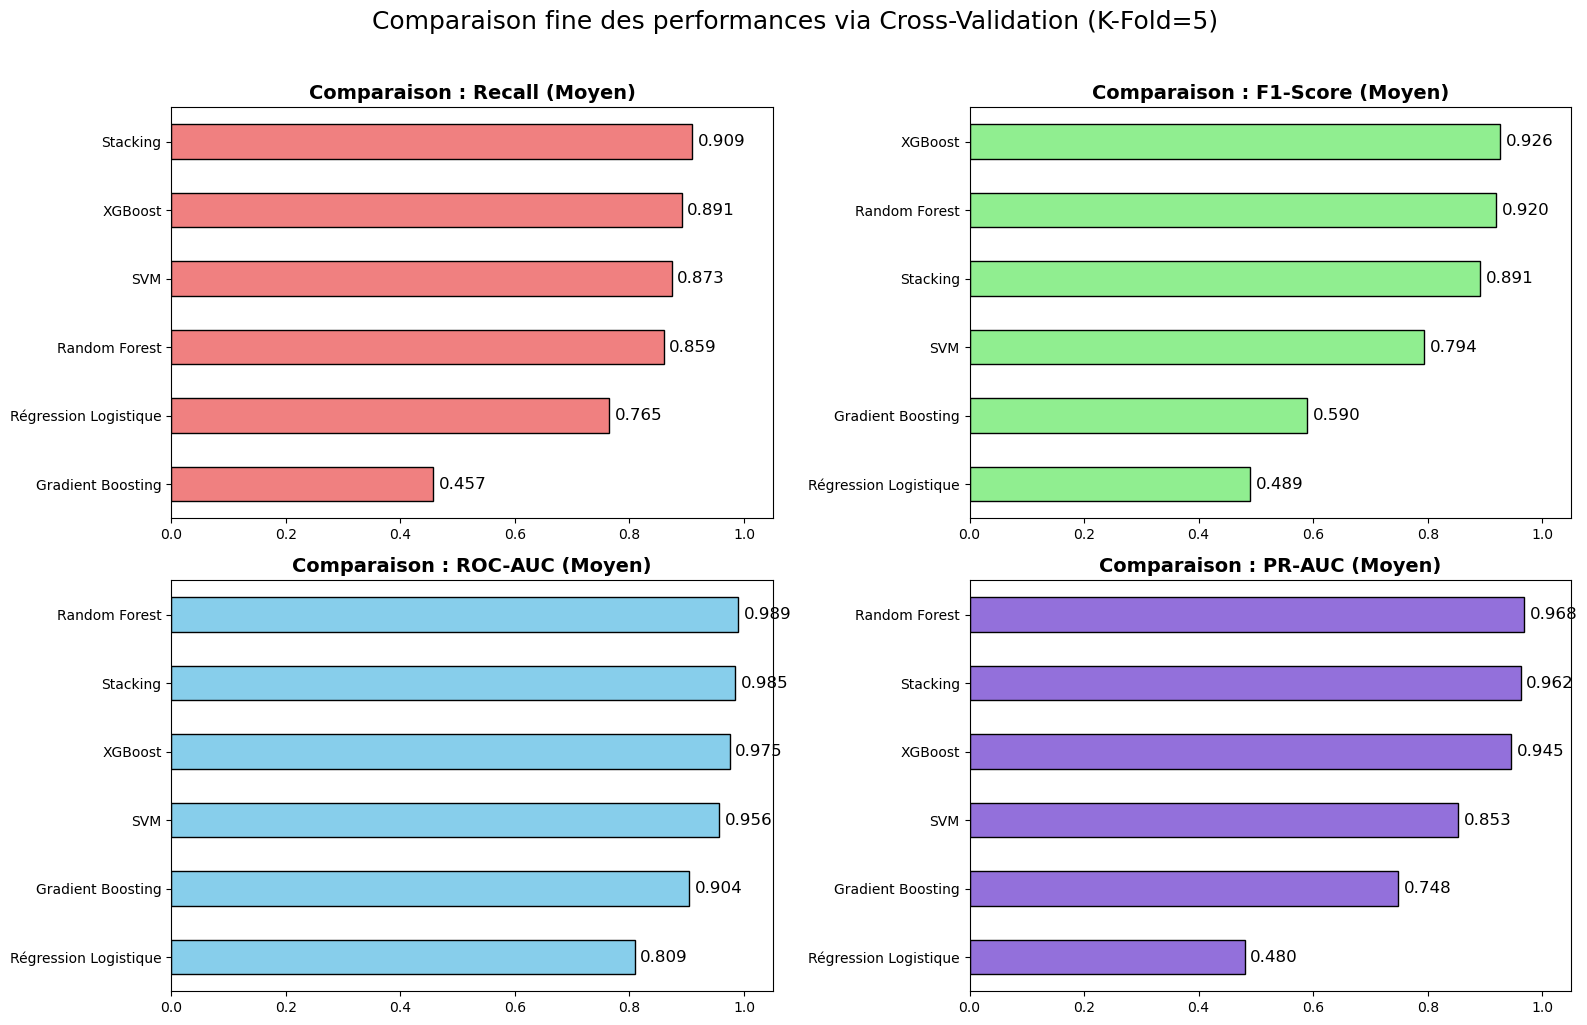

In [41]:
# Brique 33 - Comparaison visuelle des métriques de CV

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
metrics_to_plot = ['Recall (Moyen)', 'F1-Score (Moyen)', 'ROC-AUC (Moyen)', 'PR-AUC (Moyen)']
colors = ['lightcoral', 'lightgreen', 'skyblue', 'mediumpurple']

# Graphiques en barres horizontales pour une meilleure lisibilité
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i//2, i%2]
    # Tri par la valeur de la métrique en cours
    data_sorted = df_cv_results[metric].sort_values()
    data_sorted.plot(kind='barh', ax=ax, color=colors[i], edgecolor='black')
    
    ax.set_title(f'Comparaison : {metric}', fontsize=14, weight='bold')
    ax.set_xlim(0, 1.05)
    
    # Affichage des valeurs exactes à la fin des barres
    for index, value in enumerate(data_sorted):
        ax.text(value + 0.01, index, f'{value:.3f}', va='center', fontsize=12)

plt.suptitle("Comparaison fine des performances via Cross-Validation (K-Fold=5)", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# 4. Courbe Precision-Recall (Graphe de Décision Final)
L'aire sous la courbe Precision-Recall (PR-AUC) est l'indicateur roi pour l'attrition. Plus on cherche à atteindre un Rappel parfait (capter tous les gens qui partent), plus la Précision risque de chuter (on se trompe sur les gens qui vont rester). Les modèles qui gardent une pente haute sont ceux vers qui il faut s'orienter !

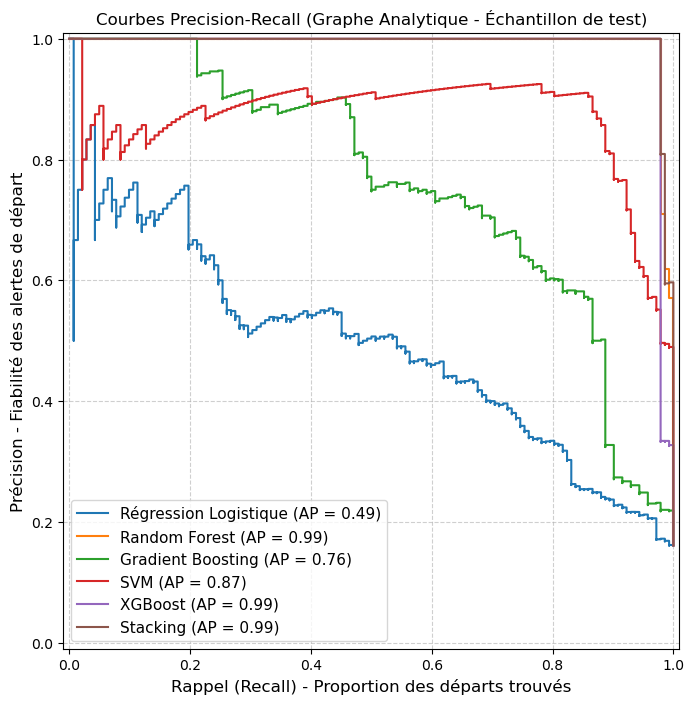

In [42]:
# Brique 34 - Courbes Precision-Recall comparatives
from sklearn.metrics import PrecisionRecallDisplay

fig, ax = plt.subplots(figsize=(10, 8))

for name, p_line in pipelines_to_compare.items():
    # Ici on observe les prédictions finales sur le set de test/validation non touché
    PrecisionRecallDisplay.from_estimator(p_line, X_valid, y_valid, ax=ax, name=name)

ax.set_title("Courbes Precision-Recall (Graphe Analytique - Échantillon de test)")
plt.legend(loc="lower left", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlabel("Rappel (Recall) - Proportion des départs trouvés", fontsize=12)
plt.ylabel("Précision - Fiabilité des alertes de départ", fontsize=12)
plt.show()

# Interprétabilité du modèle : Feature Importances & SHAP
Afin de comprendre pourquoi un employé quitte l'entreprise, nous regardons l'importance des variables.

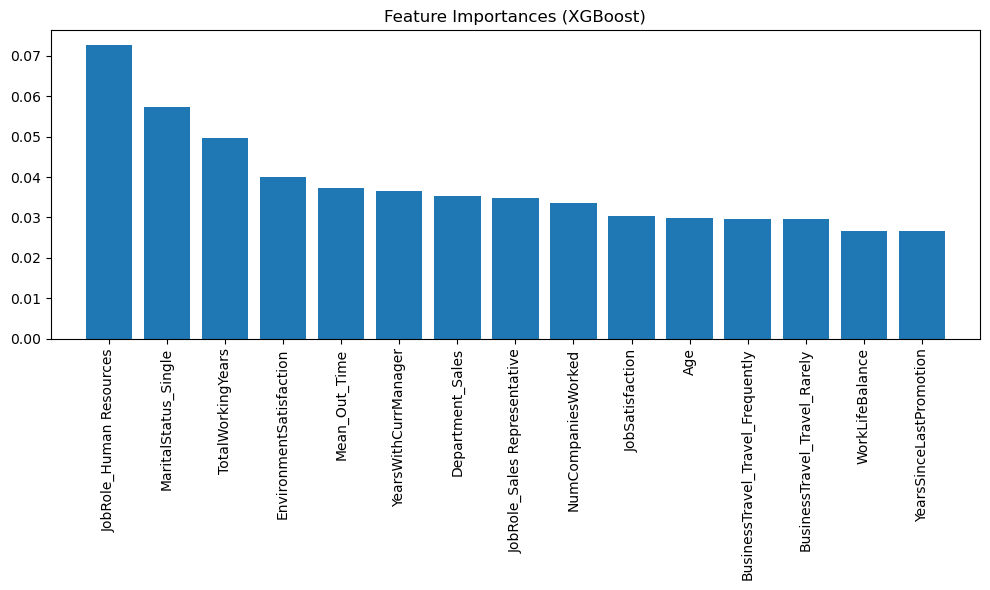

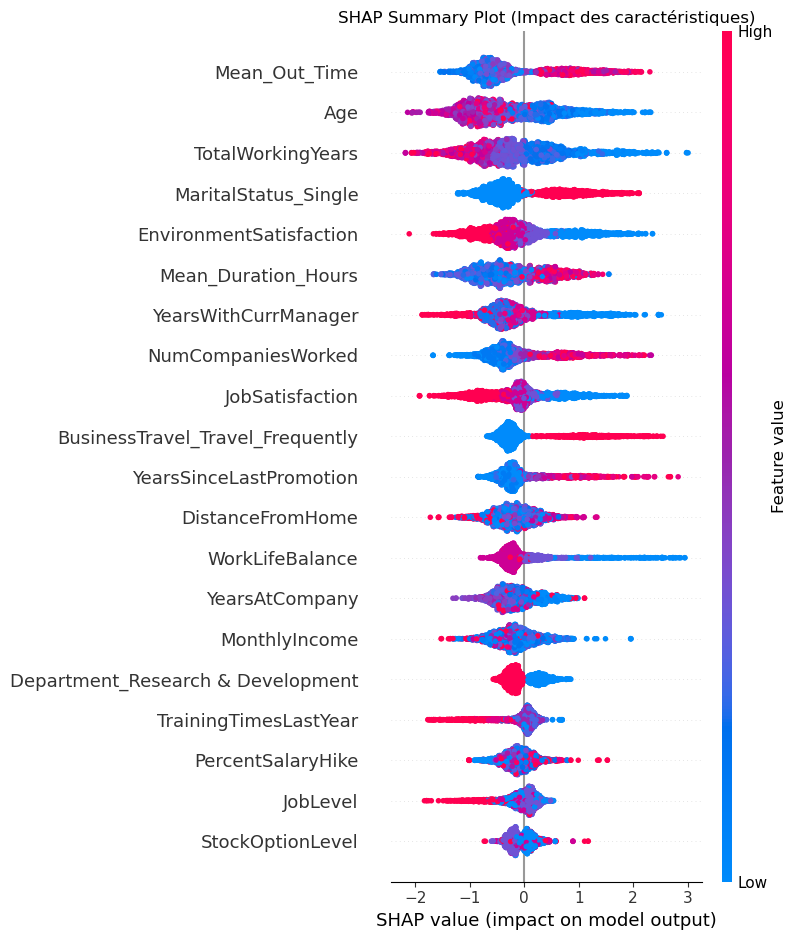

In [43]:
import shap

xgb_model = pipeline_xgb.named_steps['xgb']
X_train_scaled = pipeline_xgb.named_steps['scaler'].transform(X_train)

# Importance basique XGBoost
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importances (XGBoost)")
plt.bar(range(15), importances[indices][:15], align="center")
plt.xticks(range(15), X_train.columns[indices][:15], rotation=90)
plt.xlim([-1, 15])
plt.tight_layout()
plt.show()

# SHAP values summary
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train_scaled)

plt.figure(figsize=(12, 8))
plt.title("SHAP Summary Plot (Impact des caractéristiques)")
shap.summary_plot(shap_values, X_train_scaled, feature_names=X_train.columns)

# Fine-tuning avec RandomizedSearchCV
Optimisation des hyperparamètres du meilleur modèle (ici Random Forest ou XGBoost) avec RandomizedSearchCV.

In [44]:
from sklearn.model_selection import RandomizedSearchCV

# Définition de la grille
param_grid = {
    'xgb__n_estimators': [100, 200, 500],
    'xgb__max_depth': [3, 5, 10],
    'xgb__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0]
}

# Randomized Search
random_search = RandomizedSearchCV(
    pipeline_xgb, 
    param_distributions=param_grid, 
    n_iter=10, # Nombre d'essais pour gagner du temps
    scoring='f1', # Optimisation pour le F1-Score
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42), 
    verbose=1, 
    random_state=42, 
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres trouvés :")
print(random_search.best_params_)
print(f"Meilleur F1-Score (Cross-Validation) : {random_search.best_score_:.4f}")

# Évaluation du meilleur modèle sur le test set
best_xgb = random_search.best_estimator_
y_pred_best = best_xgb.predict(X_valid)

print("\nRapport du modèle optimisé sur Validation:")
print(classification_report(y_valid, y_pred_best))

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:36:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:36:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:36:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/home/alban/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:36:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "class_weight", "use_label_encoder" } are not use

Meilleurs hyperparamètres trouvés :
{'xgb__subsample': 1.0, 'xgb__n_estimators': 500, 'xgb__max_depth': 5, 'xgb__learning_rate': 0.2, 'xgb__colsample_bytree': 0.8}
Meilleur F1-Score (Cross-Validation) : 0.8876

Rapport du modèle optimisé sur Validation:
              precision    recall  f1-score   support

         0.0       0.99      1.00      1.00       740
         1.0       1.00      0.97      0.99       142

    accuracy                           1.00       882
   macro avg       1.00      0.99      0.99       882
weighted avg       1.00      1.00      1.00       882

